# Notebook 3 — Value Bets & Comparaison Bookmakers

**Groupe 02** — Bayesian Sports Analytics · Premier League  
Cian Higgins · Jules Dantin · Hugo Ferré

---

## Objectif

Identifier les **value bets** : paris où notre modèle Bayésien estime une probabilité
**supérieure** à celle implicite dans les cotes du bookmaker (Bet365).

**Expected Value (EV)** d'un pari :
$$\text{EV} = p_{model} \times \text{cote} - 1$$

Un pari a une valeur positive quand $\text{EV} > 0$.

**Critère de Kelly** — fraction optimale du bankroll :
$$f^* = \frac{p_{model} \times \text{cote} - 1}{\text{cote} - 1}$$

In [5]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import arviz as az
import warnings
warnings.filterwarnings('ignore')

from src.data.fetch_data import fetch_all_seasons, prepare_dataset, train_test_split_by_matchweek
from src.models.bayesian_model import build_model, sample_model, predict_all_matches
from src.analysis.predictions import evaluate_predictions
from src.analysis.value_bets import find_value_bets, backtest_strategy, summary_stats

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

## 1. Préparation des données + inférence

In [6]:
raw = fetch_all_seasons(['2022-23', '2023-24', '2024-25'])
df, teams, team_to_idx = prepare_dataset(raw)
train, test = train_test_split_by_matchweek(df, test_matchweeks=5)

# Note : si vous avez déjà sampléle modèle dans le notebook 02,
# vous pouvez charger idata depuis un fichier netCDF pour éviter de resampleler :
#   idata = az.from_netcdf('../docs/idata_static.nc')

model = build_model(train, len(teams))
idata = sample_model(model, draws=2000, tune=1000, chains=4)

Fetching season 2022-23...
Fetching season 2023-24...
Fetching season 2024-25...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_att, mu_def, sigma_att, sigma_def, attack_raw, defense, home_adv, intercept]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [7]:
# Sauvegarder pour réutilisation
idata.to_netcdf('../docs/idata_static.nc')
print('Modèle sauvegardé → docs/idata_static.nc')

Modèle sauvegardé → docs/idata_static.nc


## 2. Génération des prédictions avec cotes

In [8]:
test_aligned = test.copy().reset_index(drop=True)
test_aligned['home_idx'] = test_aligned['HomeTeam'].map(team_to_idx)
test_aligned['away_idx'] = test_aligned['AwayTeam'].map(team_to_idx)

pred_df = predict_all_matches(idata, test_aligned, teams)

# Ajouter les cotes
odds_cols = [c for c in ['B365H', 'B365D', 'B365A'] if c in test_aligned.columns]
pred_df = pred_df.merge(
    test_aligned[['HomeTeam', 'AwayTeam', 'Date'] + odds_cols],
    on=['HomeTeam', 'AwayTeam', 'Date'], how='left'
)

print(f'Matchs avec cotes disponibles : {pred_df["B365H"].notna().sum()} / {len(pred_df)}')
pred_df[['HomeTeam', 'AwayTeam', 'p_home', 'p_draw', 'p_away'] + odds_cols].head(8)

Matchs avec cotes disponibles : 20 / 20


,HomeTeam,AwayTeam,p_home,p_draw,p_away,B365H,B365D,B365A
0,Aston Villa,Tottenham,0.48150,0.21325,0.30525,1.30,6.00,8.50
1,Chelsea,Man United,0.47000,0.25050,0.27950,1.44,5.00,6.25
2,Leicester,Ipswich,0.48000,0.22825,0.29175,2.30,3.60,2.90
3,Brentford,Fulham,0.46925,0.24000,0.29075,1.91,3.90,3.60
4,Arsenal,Newcastle,0.56225,0.21750,0.22025,1.95,3.70,3.70
5,Everton,Southampton,0.55375,0.25975,0.18650,1.40,4.75,7.50
6,West Ham,Nott'm Forest,0.42925,0.24650,0.32425,2.75,3.30,2.55
7,Brighton,Liverpool,0.26875,0.23600,0.49525,2.60,3.75,2.45


## 3. Comparaison : modèle vs bookmakers

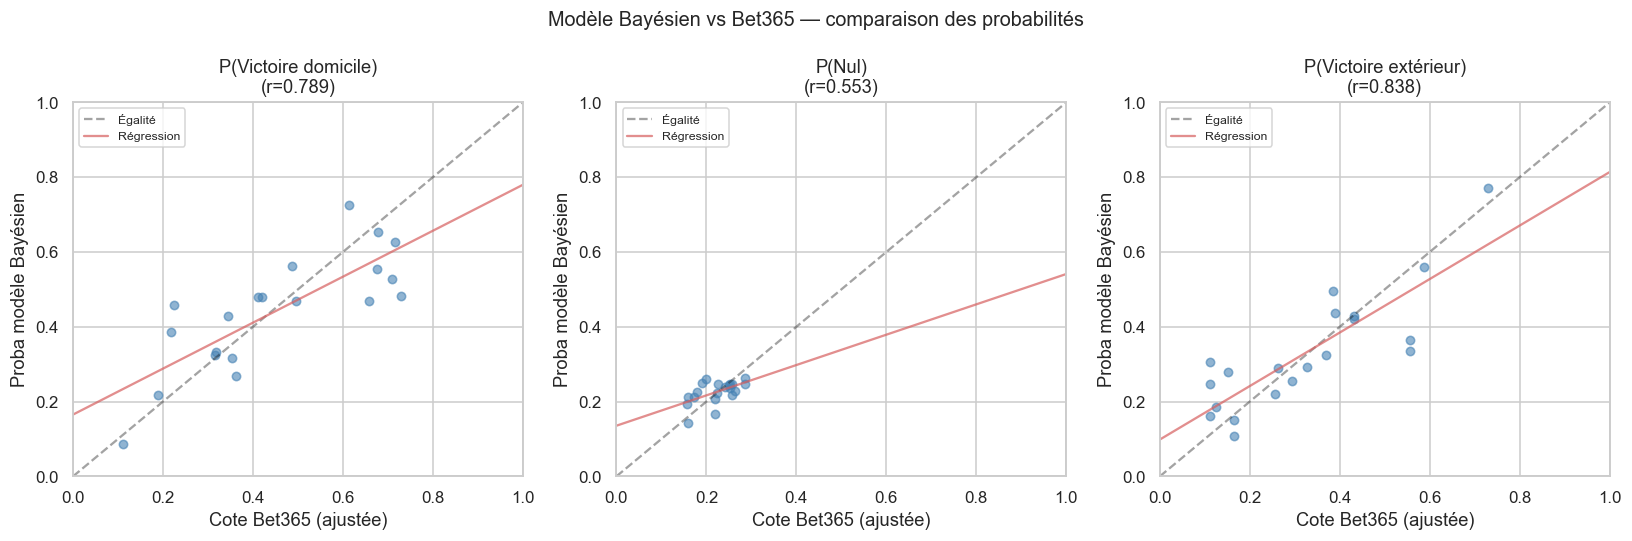

In [9]:
pred_odds = pred_df.dropna(subset=['B365H', 'B365D', 'B365A']).copy()

# Probabilités implicites (ajustées pour la marge)
raw_imp = 1.0 / pred_odds[['B365H', 'B365D', 'B365A']].values
margin  = raw_imp.sum(axis=1, keepdims=True)
adj_imp = raw_imp / margin

pred_odds['bk_home'] = adj_imp[:, 0]
pred_odds['bk_draw'] = adj_imp[:, 1]
pred_odds['bk_away'] = adj_imp[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (model_col, bk_col), title in zip(
    axes,
    [('p_home', 'bk_home'), ('p_draw', 'bk_draw'), ('p_away', 'bk_away')],
    ['P(Victoire domicile)', 'P(Nul)', 'P(Victoire extérieur)']
):
    ax.scatter(pred_odds[bk_col], pred_odds[model_col],
               alpha=0.6, s=30, color='steelblue')
    lims = [0, 1]
    ax.plot(lims, lims, 'k--', alpha=0.4, label='Égalité')
    
    # Régression
    valid = pred_odds[[bk_col, model_col]].dropna()
    z = np.polyfit(valid[bk_col], valid[model_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, p(x_line), 'r-', alpha=0.7, label=f'Régression')
    
    corr = valid[bk_col].corr(valid[model_col])
    ax.set_xlabel('Cote Bet365 (ajustée)')
    ax.set_ylabel('Proba modèle Bayésien')
    ax.set_title(f'{title}\n(r={corr:.3f})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Modèle Bayésien vs Bet365 — comparaison des probabilités', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/figures/model_vs_bookmaker.png', bbox_inches='tight')
plt.show()

## 4. Identification des value bets

In [10]:
value_bets = find_value_bets(pred_odds, min_ev=0.03, max_kelly=0.20)

print(f'Value bets identifiés : {len(value_bets)}')
if not value_bets.empty:
    print(f'EV moyen : {value_bets["ev"].mean():.3f}')
    print(f'Edge moyen : {value_bets["edge"].mean():.3f}')
    value_bets.head(15)

Value bets identifiés : 23
EV moyen : 0.354
Edge moyen : 0.069


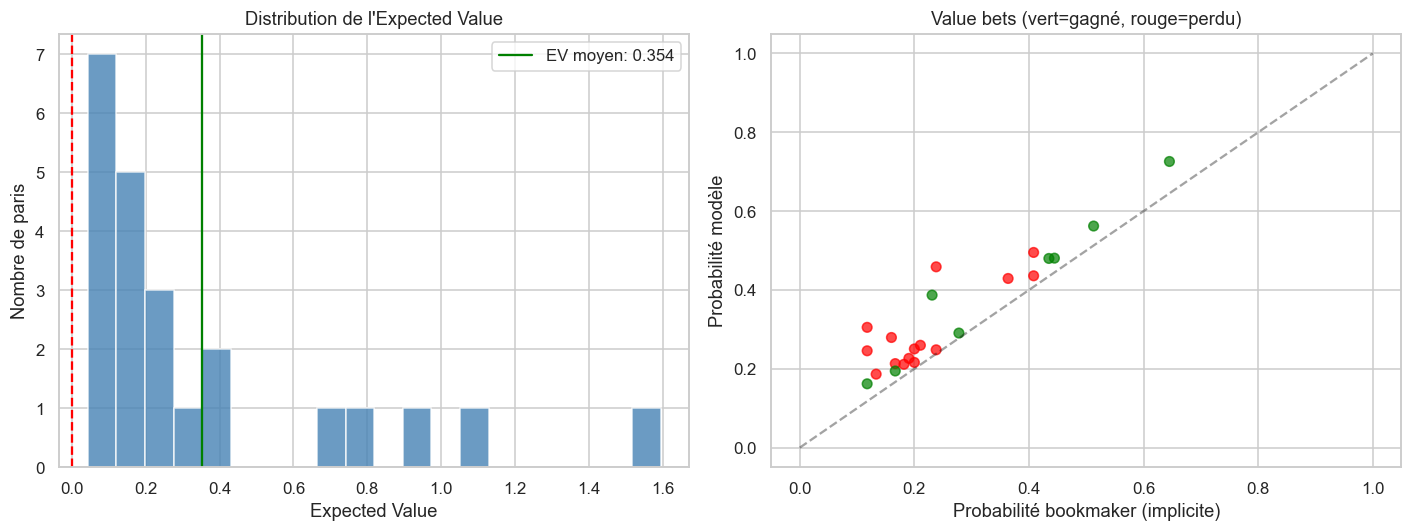

In [11]:
if not value_bets.empty and 'won' in value_bets.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Distribution EV
    axes[0].hist(value_bets['ev'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].axvline(value_bets['ev'].mean(), color='green', linestyle='-',
                    label=f'EV moyen: {value_bets["ev"].mean():.3f}')
    axes[0].set_xlabel('Expected Value')
    axes[0].set_ylabel('Nombre de paris')
    axes[0].set_title('Distribution de l\'Expected Value')
    axes[0].legend()

    # Edge (modèle - bookmaker)
    colors = ['green' if w else 'red' for w in value_bets['won']]
    axes[1].scatter(value_bets['p_implied'], value_bets['p_model'],
                    c=colors, alpha=0.7, s=40)
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[1].set_xlabel('Probabilité bookmaker (implicite)')
    axes[1].set_ylabel('Probabilité modèle')
    axes[1].set_title('Value bets (vert=gagné, rouge=perdu)')

    plt.tight_layout()
    plt.savefig('../docs/figures/value_bets_scatter.png', bbox_inches='tight')
    plt.show()

## 5. Backtesting de la stratégie

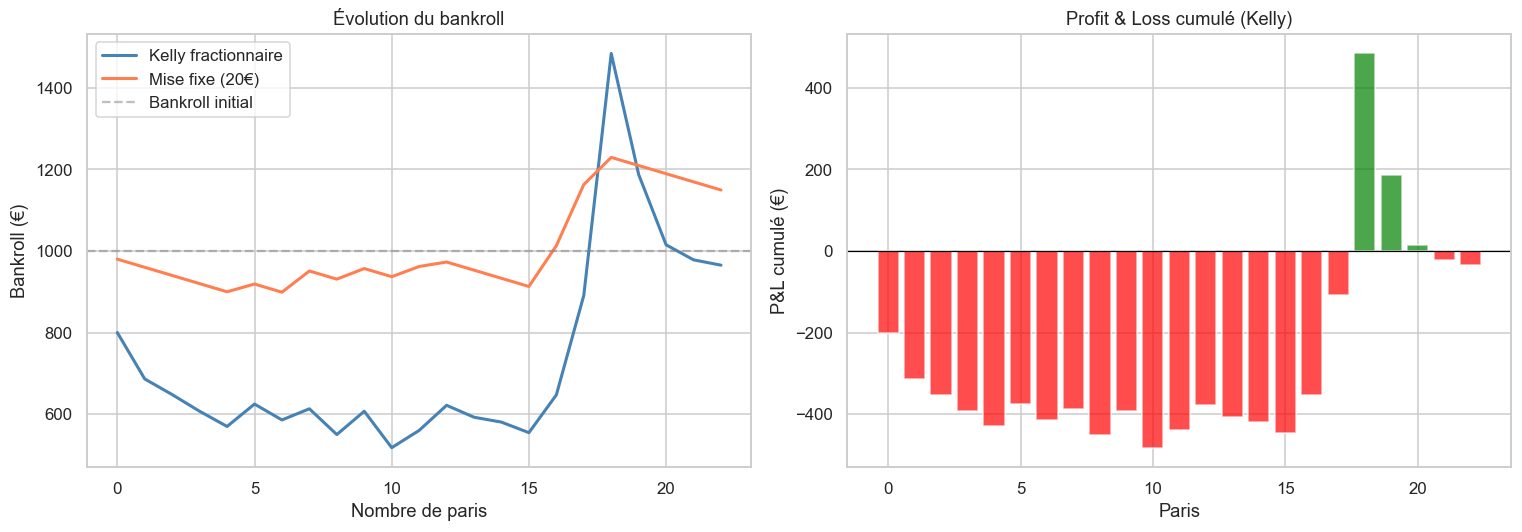

=== Résumé Kelly ===
  n_bets               : 23
  win_rate             : 0.3478
  total_profit         : -34.7306
  roi                  : -0.0205
  max_drawdown         : 519.1648
  final_bankroll       : 965.2694

=== Résumé Mise fixe ===
  n_bets               : 23
  win_rate             : 0.3478
  total_profit         : 149.6000
  roi                  : 0.3252
  max_drawdown         : 81.0000
  final_bankroll       : 1149.6000


In [12]:
if not value_bets.empty and 'won' in value_bets.columns:
    bt_kelly = backtest_strategy(value_bets, initial_bankroll=1000, bet_fraction='kelly')
    bt_flat  = backtest_strategy(value_bets, initial_bankroll=1000, bet_fraction='flat', flat_stake=20)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Evolution du bankroll
    axes[0].plot(range(len(bt_kelly)), bt_kelly['bankroll'],
                 label='Kelly fractionnaire', color='steelblue', lw=2)
    axes[0].plot(range(len(bt_flat)), bt_flat['bankroll'],
                 label='Mise fixe (20€)', color='coral', lw=2)
    axes[0].axhline(1000, color='gray', linestyle='--', alpha=0.5, label='Bankroll initial')
    axes[0].set_xlabel('Nombre de paris')
    axes[0].set_ylabel('Bankroll (€)')
    axes[0].set_title('Évolution du bankroll')
    axes[0].legend()

    # P&L cumulé
    axes[1].bar(range(len(bt_kelly)), bt_kelly['profit'].cumsum(),
                color=['green' if p > 0 else 'red' for p in bt_kelly['profit'].cumsum()],
                alpha=0.7)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Paris')
    axes[1].set_ylabel('P&L cumulé (€)')
    axes[1].set_title('Profit & Loss cumulé (Kelly)')

    plt.tight_layout()
    plt.savefig('../docs/figures/backtest_results.png', bbox_inches='tight')
    plt.show()

    print('=== Résumé Kelly ===' )
    stats_k = summary_stats(bt_kelly)
    for k, v in stats_k.items():
        print(f'  {k:20s} : {v:.4f}' if isinstance(v, float) else f'  {k:20s} : {v}')

    print('\n=== Résumé Mise fixe ===')
    stats_f = summary_stats(bt_flat)
    for k, v in stats_f.items():
        print(f'  {k:20s} : {v:.4f}' if isinstance(v, float) else f'  {k:20s} : {v}')

## 6. Marge bookmaker vs edge modèle

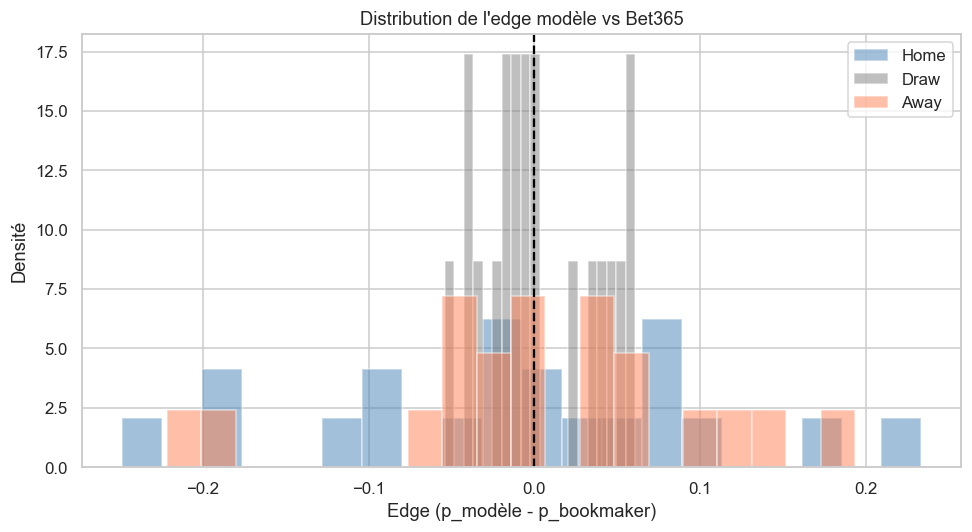

In [13]:
pred_odds['margin'] = (1/pred_odds['B365H'] + 1/pred_odds['B365D'] + 1/pred_odds['B365A'] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 5))

# Edge par outcome
for outcome, pcol, bcol, color in [
    ('Home', 'p_home', 'bk_home', 'steelblue'),
    ('Draw', 'p_draw', 'bk_draw', 'gray'),
    ('Away', 'p_away', 'bk_away', 'coral'),
]:
    edge = pred_odds[pcol] - pred_odds[bcol]
    ax.hist(edge, bins=20, alpha=0.5, color=color, label=outcome, density=True)

ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Edge (p_modèle - p_bookmaker)')
ax.set_ylabel('Densité')
ax.set_title('Distribution de l\'edge modèle vs Bet365')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/figures/edge_distribution.png', bbox_inches='tight')
plt.show()

## Conclusions

| Metric | Valeur |
|---|---|
| Value bets identifiés | voir ci-dessus |
| Taux de réussite | voir backtest |
| ROI Kelly | voir backtest |

**Interprétation** :
- Un modèle Bayésien hiérarchique permet d'identifier des divergences avec les bookmakers
- Les value bets positifs représentent les matchs où notre incertitude est mieux quantifiée
- La stratégie Kelly limite le risque de ruine tout en maximisant la croissance du bankroll
- **Limite** : ce backtest est sur un petit échantillon (5 semaines) — à interpréter avec prudence

**Voir notebook 04** pour le modèle dynamique (force évoluant dans le temps).